# Decision Tree - Bagging - Random Forest

Vamos a utilizar el siguiente dataset: https://www.kaggle.com/jsphyg/weather-dataset-rattle-package

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

In [2]:
df = pd.read_csv("weather.csv")

In [3]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


Vamos a descartar las columnas:

- Sunshine
- Evaporation
- Cloud3pm
- Cloud9am
- Location
- Date
- WindGustDir
- WindDir9am

In [4]:
df =df.drop(['Sunshine','Evaporation','Cloud3pm','Cloud9am','Location','Date','WindGustDir','WindDir9am'], axis = 1)

In [5]:
df.shape

(145460, 15)

Descartar todas las filas que tengan nulos:

In [6]:
df =df.dropna(axis =0)

In [7]:
df.shape

(119016, 15)

Separamos en X e y. Nuestro objetivo es predecir si va a llover mañana.

In [8]:
X = df.drop('RainTomorrow', axis =1)
y = df.RainTomorrow.copy()

Aplicamos pd.get_dummies() a las features categóricas.

In [9]:
X = pd.get_dummies(X).astype('int')
X.head()

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,...,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,RainToday_No,RainToday_Yes
0,13,22,0,44,20,24,71,22,1007,1007,...,0,0,0,0,0,0,1,0,1,0
1,7,25,0,44,4,22,44,25,1010,1007,...,0,0,0,0,0,0,0,1,1,0
2,12,25,0,46,19,26,38,30,1007,1008,...,0,0,0,0,0,0,0,1,1,0
3,9,28,0,24,11,9,45,16,1017,1012,...,0,0,0,0,0,0,0,0,1,0
4,17,32,1,41,7,20,82,33,1010,1006,...,0,0,0,0,0,0,0,0,1,0


Llevar el target a una variable numérica:

- 1 si va a llover mañana
- 0 si no va a llover mañana

In [10]:
y = y.map({'Yes': 1,'No': 0})   #np.where('RainTomorrow' == 'Yes', 1, 0)
y

0         0
1         0
2         0
3         0
4         0
         ..
145454    0
145455    0
145456    0
145457    0
145458    0
Name: RainTomorrow, Length: 119016, dtype: int64

In [11]:
y.value_counts('%')

0    0.781508
1    0.218492
Name: RainTomorrow, dtype: float64

Aplicamos train test split. El set de test tendrá un 20% de los datos con un random state de 42 y stratify.

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##Entrenamiento de modelos

### Decision Tree

Entrenar un arbol de decision con:
- max_depth=10
- random_state=0

y obtener el classification report para train y test.

In [14]:
decision_tree = DecisionTreeClassifier(max_depth=10, random_state=0)

In [15]:
%%time
decision_tree.fit(X_train, y_train)

CPU times: total: 1.09 s
Wall time: 1.56 s


DecisionTreeClassifier(max_depth=10, random_state=0)

In [16]:
pred_test = decision_tree.predict(X_test)

###Bagging

Ahora, usar un Bagging Classifier armado con árboles de decisión:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html

Los árboles que usemos en este clasificador, deberán tener la misma profundidad máxima (max_depth) que el árbol que entrenamos recién.

Además usar:

- n_estimators = 200
- n_jobs = -1 -> ¿Qué pasa si sacamos esto?
- random_state = 0 -> En el arbol y en el BaggingClassifier

In [17]:
bagging = BaggingClassifier(estimator= DecisionTreeClassifier(max_depth = 10,random_state=0),
                       n_estimators=200,n_jobs = -1, random_state=0)

In [18]:
%%time
bagging.fit(X_train,y_train)


CPU times: total: 219 ms
Wall time: 1min 30s


BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=10,
                                                   random_state=0),
                  n_estimators=200, n_jobs=-1, random_state=0)

In [19]:
pred_test = bagging.predict(X_test)

###Random Forest

Ahora, probar con un RandomForestClassifier.

Los hiperparámetros serán igual que los anteriores:

- max_depth=10
- n_estimators=200
- n_jobs=-1
- random_state=0

In [20]:
random_forest = RandomForestClassifier(max_depth=10,n_estimators=200, n_jobs=-1, random_state=0)

In [21]:
%%time
random_forest.fit(X_train,y_train)

CPU times: total: 47.9 s
Wall time: 16.1 s


RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1,
                       random_state=0)

In [22]:
pred_test = random_forest.predict(X_test)

##Evaluación de modelos

In [23]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    precision = round(precision_score(y_test, y_pred), 2)
    recall = round(recall_score(y_test, y_pred), 2)
    f1 = round(f1_score(y_test, y_pred), 2)
    roc_auc = round(roc_auc_score(y_test, y_proba), 2)
    prc_auc = round(average_precision_score(y_test, y_proba), 2)

    return (precision, recall, f1, roc_auc, prc_auc)

In [24]:
results = []

model_names= ['DecisionTree', 'Bagging', 'RandomForest']
best_models= [decision_tree, bagging,  random_forest]

for name, model in zip(model_names, best_models):
    if name == 'LogisticRegression':
        precision, recall, f1, roc_auc, prc_auc = evaluate_model(model, X_test, y_test)
    else:
        precision, recall, f1, roc_auc, prc_auc = evaluate_model(model, X_test, y_test)

    results.append(pd.DataFrame({"Model": [name], "Precisión": [precision], "Recall": [recall], "f1 score": [f1], "roc auc": [roc_auc], "prc auc": [prc_auc] }))

results = pd.concat(results).reset_index(drop=True)

print("\nResultados de evaluación de modelos:")
results.head(3)


Resultados de evaluación de modelos:


,Model,Precisión,Recall,f1 score,roc auc,prc auc
0,DecisionTree,0.69,0.50,0.58,0.84,0.64
1,Bagging,0.76,0.50,0.60,0.88,0.72
2,RandomForest,0.78,0.45,0.57,0.87,0.71


##Selección de Features

Ahora, en el random forest, imprimir la importancia de las features:

In [25]:
random_forest.feature_importances_

array([0.02507136, 0.02525147, 0.07740893, 0.07294302, 0.01389676,
       0.0183135 , 0.07772365, 0.37644434, 0.05280518, 0.06648542,
       0.01843474, 0.03862475, 0.00070512, 0.00079136, 0.00068664,
       0.00350718, 0.00180734, 0.00210084, 0.00236127, 0.00209896,
       0.00131132, 0.00085501, 0.00115437, 0.00122701, 0.00127593,
       0.00141586, 0.00190801, 0.00108075, 0.05470433, 0.05760556])

Correr el siguiente código para obtener sus feature importances:

In [26]:
fi = pd.DataFrame(columns=["FEATURE", "IMPORTANCE"])
fi["FEATURE"] = X_train.columns
fi["IMPORTANCE"] = random_forest.feature_importances_
fi = fi.sort_values("IMPORTANCE", ascending=False)

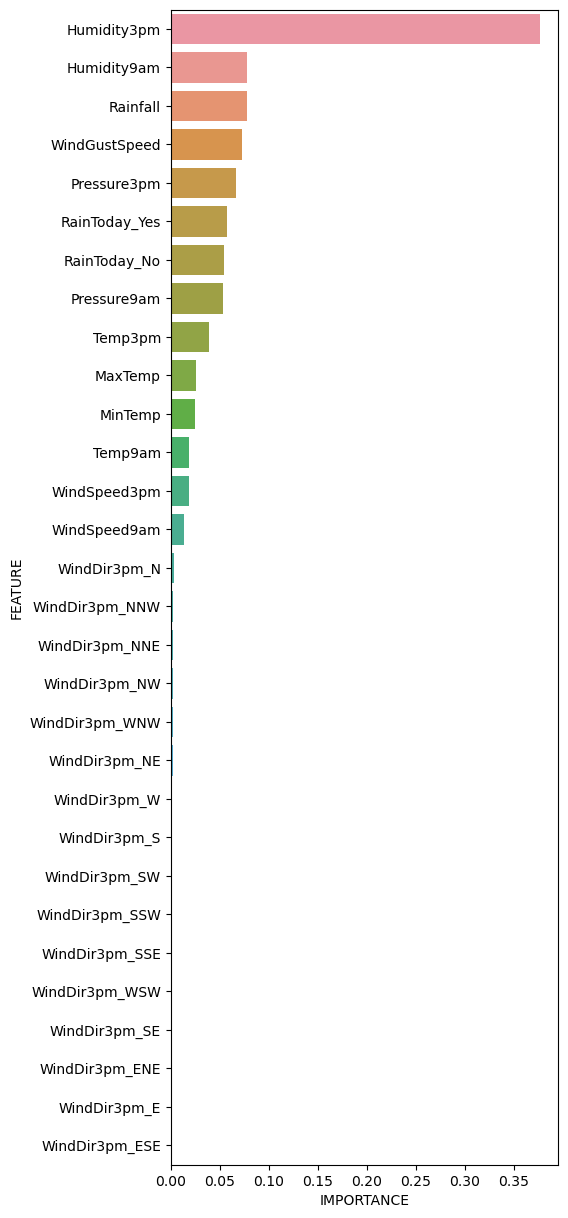

In [27]:
plt.figure(figsize=(5, 15))
sns.barplot(y=fi.FEATURE, x=fi.IMPORTANCE)
plt.show()